In [1]:
from utils import preprocessing

In [2]:
(
    X_num_train, X_cat_train,
    X_num_test,  X_cat_test,
    y_train_enc, y_test_enc,
    num_scaler,  cat_encoder,
    label_encoder
    ) = preprocessing('/mnt/d/home-2/Documentos/master/practica-deusto-tech/TFM/MyTabsyn/CorVAE/data/shppers/metadata.json', encoding='ordinal', random_state=42)


In [2]:
import numpy as np


In [3]:
a = np.load("data/shoppers/y_test.npy")
sum(a==True), sum(a==False)

(191, 1042)

In [3]:
import pandas as pd
df = pd.read_csv("checkpoint_prueba_D/metrics.csv")
display(df)

,method,IPC,model,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,cv_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,seed
0,Full-data,NaN,xgb,0.774,0.795,0.897,0.901,0.007,0.009,0.005,0.005,10.064,0.774,0.794,0.896,0.899,0.934,NaN
1,Full-data,NaN,rf,0.850,0.790,0.879,0.870,0.009,0.009,0.006,0.007,11.571,0.861,0.801,0.886,0.877,0.928,NaN
2,Full-data,NaN,svc,0.732,0.765,0.885,0.894,0.009,0.009,0.004,0.004,138.762,0.748,0.781,0.892,0.899,0.900,NaN
3,Full-data,NaN,logreg,0.676,0.716,0.866,0.882,0.006,0.005,0.002,0.002,5.560,0.705,0.750,0.882,0.895,0.903,NaN
4,random,10.0,xgb,0.950,0.947,0.947,0.950,0.100,0.107,0.107,0.100,0.460,0.802,0.695,0.804,0.777,0.879,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,random,90.0,logreg,0.789,0.787,0.787,0.789,0.048,0.049,0.049,0.048,0.080,0.788,0.711,0.824,0.804,0.862,4.0
360,k-means,90.0,xgb,0.961,0.961,0.961,0.961,0.033,0.033,0.033,0.033,0.353,0.787,0.629,0.731,0.688,0.880,4.0
361,k-means,90.0,rf,0.967,0.967,0.967,0.967,0.032,0.033,0.033,0.032,1.958,0.500,0.135,0.043,0.156,0.885,4.0
362,k-means,90.0,svc,0.833,0.833,0.833,0.833,0.053,0.053,0.053,0.053,0.122,0.792,0.693,0.804,0.778,0.860,4.0


In [11]:
filter = df.groupby(['method', 'IPC','model']).agg({
    'test_balanced': 'mean',
    'test_roc_auc': 'mean'
}).reset_index()

In [25]:
filter2 = df.groupby(['method']).agg({
    'test_balanced': 'mean',
    'test_roc_auc': 'mean'
}).reset_index()
filter2.loc[filter2['method'] == 'Full-data']

,method,test_balanced,test_roc_auc
0,Full-data,0.772,0.91625


In [28]:
import numpy as np
filter.loc[
    filter['method'].isin(['k-means', 'random', 'Full-data'])
    &
    (
        (filter['IPC'] == 90)
        | 
        (filter['IPC'] == None)
    )
]

,method,IPC,model,test_balanced,test_roc_auc
32,k-means,90.0,logreg,0.7314,0.8008
33,k-means,90.0,rf,0.5000,0.8806
34,k-means,90.0,svc,0.7992,0.8926
35,k-means,90.0,xgb,0.5876,0.8812
68,random,90.0,logreg,0.7998,0.8728
69,random,90.0,rf,0.8116,0.8772
70,random,90.0,svc,0.7924,0.8666
71,random,90.0,xgb,0.8360,0.8964


In [ ]:
import pandas as pd
df = pd.read_csv("checkpoint_prueba_C/relative_regret.csv")
display(df)

In [ ]:
import pandas as pd
df = pd.read_csv("checkpoint_prueba_D/relative_regret.csv")
display(df)

In [ ]:
import pandas as pd
df_d = pd.read_csv("checkpoint_prueba_D/relative_regret.csv")
display(df_d)

## Observar el PCA de los datos originales y los del espacio latente

In [4]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE
from utils import read_json_config, split_train_test_custom, preprocessing
from sklearn.cluster import KMeans

In [2]:
metadata_path = 'data/shoppers/metadata.json'
config = read_json_config(metadata_path)
base_dir = os.path.dirname(metadata_path)

STATIC_SEED = 0
SEED =0

# Se utiliza un test de 0.1 porque luego se aplicar validacion cruzada que ya incluye validacion
X_train_init, y_train_init, X_test_init, y_test_init = split_train_test_custom(config, base_dir, test_size=0.1, random_state=STATIC_SEED)

set_data = (X_train_init, y_train_init, X_test_init, y_test_init)

(
    X_train_pre, X_test_pre,
    y_train_pre, y_test_pre,
    num_scaler,  cat_encoder,
    label_encoder
                    ) = preprocessing(config, X_train_init, y_train_init, X_test_init, y_test_init, encoding='one-hot', concat=True, random_state=SEED)


Datos de train y test guardados en data/shoppers


### Visualización en el espacio original

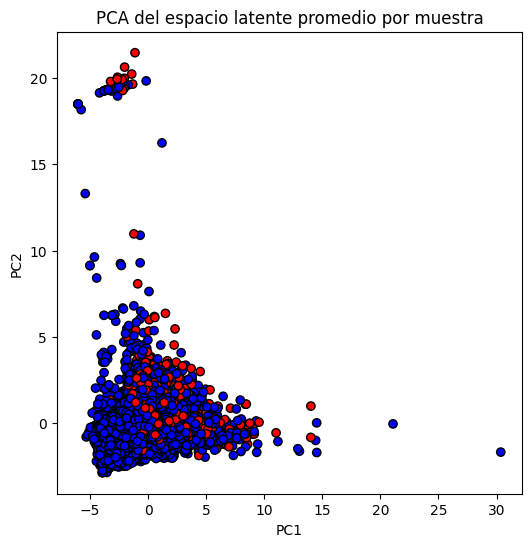

In [3]:
# 1) resumir cada muestra, p. ej. promedio en t
# 2) PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_train_pre)      # o X_mean
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)  # ahora (n,2)

# 3) plot
plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=y_train_pre, cmap='bwr', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA del espacio latente promedio por muestra')
plt.show()

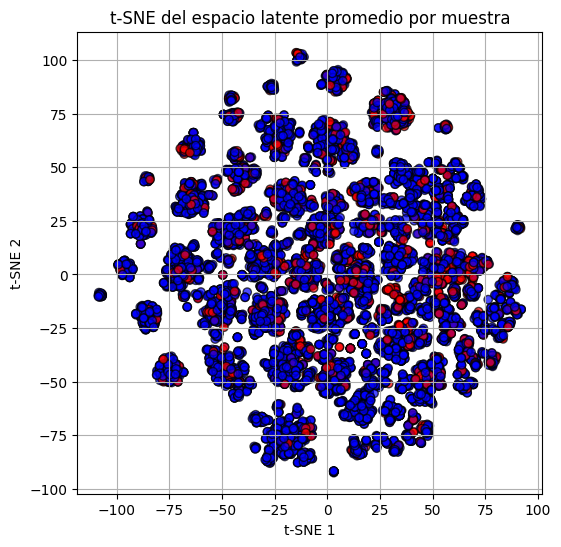

In [9]:
# 3) escalar
X_scaled = StandardScaler().fit_transform(X_train_pre)

# 4) aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X2 = tsne.fit_transform(X_scaled)

# 5) plot
plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=y_train_pre, cmap='bwr', edgecolor='k', alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE del espacio latente promedio por muestra')
plt.grid(True)
plt.show()

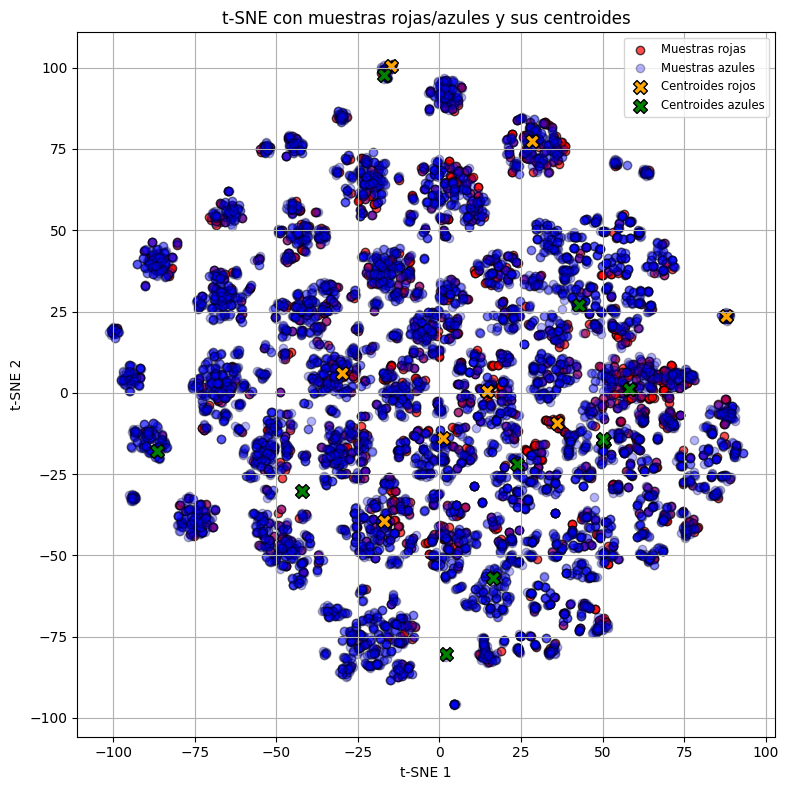

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- Asume que ya tienes X_train_pre (n_samples × n_features) y y_train_pre (n_samples,) cargados ---

# 1) Escalado del espacio original
X_scaled = StandardScaler().fit_transform(X_train_pre)

# 2) Define tu clase de interés (la que pintarás en rojo)
label_rojo = 1  # ajústalo al valor de etiqueta que quieras destacar

# 3) K-means por grupo: clase roja vs. resto (10 clusters cada uno)
centers_list = []
centers_labels = []

for is_rojo in [True, False]:
    mask = (y_train_pre == label_rojo) if is_rojo else (y_train_pre != label_rojo)
    X_sub = X_scaled[mask]
    kmeans = KMeans(n_clusters=10, random_state=42).fit(X_sub)
    centers = kmeans.cluster_centers_
    centers_list.append(centers)
    centers_labels.extend([is_rojo] * centers.shape[0])

centers_all = np.vstack(centers_list)
centers_labels = np.array(centers_labels)  # True=rojo, False=azul

# 4) Proyección conjunta con t-SNE (muestras + centroides)
X_combined = np.vstack((X_scaled, centers_all))
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X2_combined = tsne.fit_transform(X_combined)

# separar proyecciones
X2 = X2_combined[: len(X_scaled)]
centers_2 = X2_combined[len(X_scaled) :]

# 5) Graficar
plt.figure(figsize=(8,8))

# muestras
mask_rojas = (y_train_pre == label_rojo)
plt.scatter(
    X2[mask_rojas, 0], X2[mask_rojas, 1],
    color='red', edgecolor='k', alpha=0.7,
    label='Muestras rojas'
)
plt.scatter(
    X2[~mask_rojas, 0], X2[~mask_rojas, 1],
    color='blue', edgecolor='k', alpha=0.3,
    label='Muestras azules'
)

# centroides
plt.scatter(
    centers_2[centers_labels, 0], centers_2[centers_labels, 1],
    color='orange', marker='X', s=100, edgecolor='k',
    label='Centroides rojos'
)
plt.scatter(
    centers_2[~centers_labels, 0], centers_2[~centers_labels, 1],
    color='green', marker='X', s=100, edgecolor='k',
    label='Centroides azules'
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE con muestras rojas/azules y sus centroides')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


### Visualizacion en el espacio latente

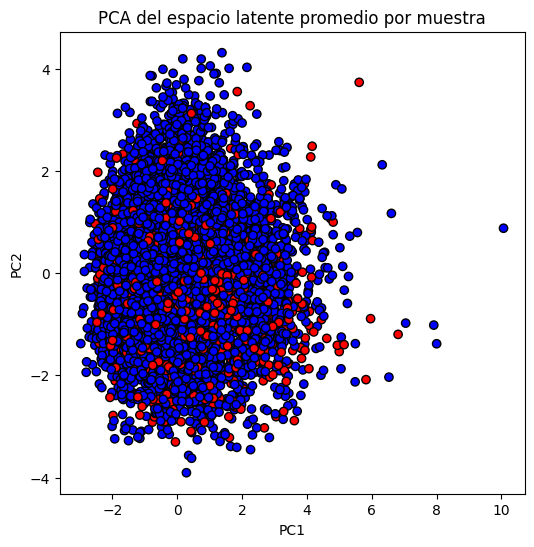

In [6]:
train_z = np.load(os.path.join('checkpoint_prueba_C', 'train_z.npy'))
train_y = np.load(os.path.join('checkpoint_prueba_C', 'train_y.npy'))

# 1) resumir cada muestra, p. ej. promedio en t
x_mean = train_z.mean(axis=1)  # ahora (n, d)
# 2) PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(x_mean)      # o X_mean
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)  # ahora (n,2)

# 3) plot
plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=train_y, cmap='bwr', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA del espacio latente promedio por muestra')
plt.show()

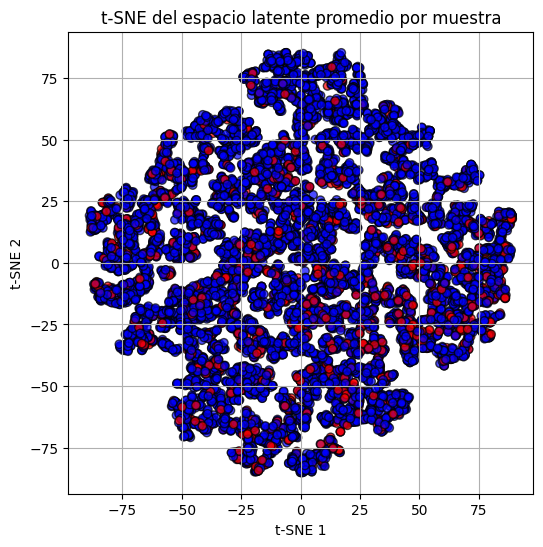

In [7]:
# 1) cargar datos
train_z = np.load(os.path.join('checkpoint_prueba_C', 'train_z.npy'))
train_y = np.load(os.path.join('checkpoint_prueba_C', 'train_y.npy'))

# 2) resumir cada muestra (promediar en t)
x_mean = train_z.mean(axis=1)  # ahora (n, d)
# 3) escalar
X_scaled = StandardScaler().fit_transform(x_mean)

# 4) aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X2 = tsne.fit_transform(X_scaled)

# 5) plot
plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=train_y, cmap='bwr', edgecolor='k', alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE del espacio latente promedio por muestra')
plt.grid(True)
plt.show()


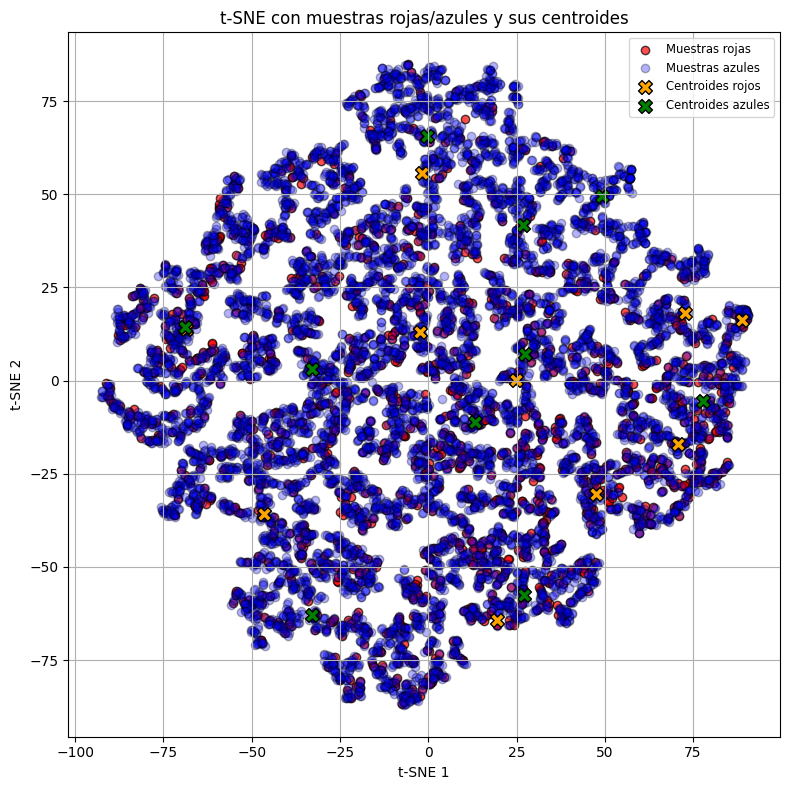

In [8]:


# --- Carga de datos latentes ---
train_z = np.load(os.path.join('checkpoint_prueba_C', 'train_z.npy'))  # (n, t, d)
train_y = np.load(os.path.join('checkpoint_prueba_C', 'train_y.npy'))  # (n,)

# --- Promedio temporal ---
x_mean = train_z.mean(axis=1)  # (n, d)

# --- Escalado ---
X_scaled = StandardScaler().fit_transform(x_mean)

# --- Define tu clase de interés (la que pintaremos en rojo) ---
label_rojo = 1  # por ejemplo, la clase "1" será roja

# --- K-means por grupo: rojo vs resto (10 clusters cada uno) ---
centers_list = []
centers_labels = []

for is_rojo in [True, False]:
    # selecciona muestras rojas o azules
    mask = (train_y == label_rojo) if is_rojo else (train_y != label_rojo)
    X_sub = X_scaled[mask]
    kmeans = KMeans(n_clusters=10, random_state=42).fit(X_sub)
    centers = kmeans.cluster_centers_
    centers_list.append(centers)
    # guardamos el flag para colorear luego
    centers_labels.extend([is_rojo] * centers.shape[0])

centers_all = np.vstack(centers_list)
centers_labels = np.array(centers_labels)  # True=rojo, False=azul

# --- Proyección conjunta con t-SNE ---
X_combined = np.vstack((X_scaled, centers_all))
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X2_combined = tsne.fit_transform(X_combined)
X2 = X2_combined[: len(X_scaled)]
centers_2 = X2_combined[len(X_scaled):]

# --- Graficar ---
plt.figure(figsize=(8,8))

# Muestras rojas y azules
mask_rojas = (train_y == label_rojo)
plt.scatter(
    X2[mask_rojas,0], X2[mask_rojas,1],
    color='red', edgecolor='k', alpha=0.7,
    label='Muestras rojas'
)
plt.scatter(
    X2[~mask_rojas,0], X2[~mask_rojas,1],
    color='blue', edgecolor='k', alpha=0.3,
    label='Muestras azules'
)

# Centroides naranjas y verdes
mask_centros_rojos = centers_labels
plt.scatter(
    centers_2[mask_centros_rojos,0], centers_2[mask_centros_rojos,1],
    color='orange', marker='X', s=100, edgecolor='k',
    label='Centroides rojos'
)
plt.scatter(
    centers_2[~mask_centros_rojos,0], centers_2[~mask_centros_rojos,1],
    color='green', marker='X', s=100, edgecolor='k',
    label='Centroides azules'
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE con muestras rojas/azules y sus centroides')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
train_z.shape

(11097, 18, 4)